# VAR Analysis Notebook

## Workflow Summary

This notebook reports a standard reduced-form VAR analysis workflow: data setup, VAR($p$) estimation by OLS, stability verification, MA representation, Cholesky identification, and impulse response analysis.

`Data` -> `Lagged Matrices (Y, X)` -> `OLS (c, A_1,...,A_p, Sigma_u)` -> `Stability` -> `MA (C_h)` -> `Cholesky (P)` -> `Structural MA (\tilde{C}_h = C_h P)`


In [93]:
# 1) Imports

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, Optional

import utils as _utils
_utils = importlib.reload(_utils)

generate_synthetic_var_data = _utils.generate_synthetic_var_data
load_time_series = _utils.load_time_series
prepare_var_data = _utils.prepare_var_data
summarize_data = _utils.summarize_data
plot_raw_series_and_correlation = _utils.plot_raw_series_and_correlation
plot_stability_eigenvalues = _utils.plot_stability_eigenvalues
plot_irf = _utils.plot_irf
plot_irf_horizon_heatmap = _utils.plot_irf_horizon_heatmap
plot_irf_by_tref = _utils.plot_irf_by_tref

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)


## 1. Data Preparation

The analysis uses a multivariate time-series matrix with variables ordered as `var_names`. Data can be imported from external files (`csv`, `xlsx`) or generated synthetically for reproducible checks.

At this stage, missing values are removed (if requested), and the cleaned data matrix is used as the common input for all subsequent computations.


Data shape: (250, 3)


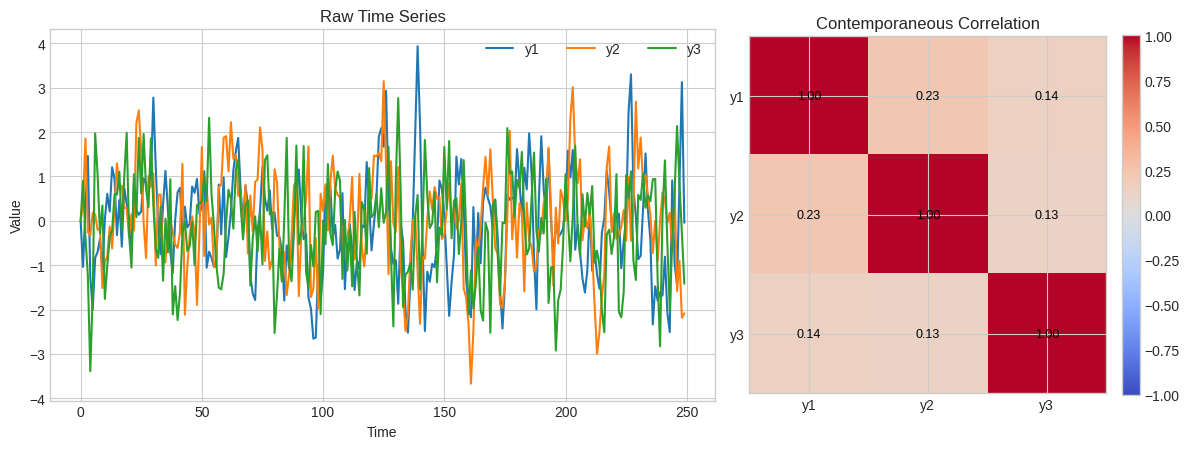

In [94]:
# 2) Data loading (functionized)

df = generate_synthetic_var_data(T=250, seed=42)
var_names = ["y1", "y2", "y3"]
data_df, data = prepare_var_data(df=df, var_names=var_names, dropna=True)

print("Data shape:", data.shape)

plot_raw_series_and_correlation(data_df=data_df, var_names=var_names)

## 2. Lag-Matrix Construction

Given lag order $p$, the VAR system is rewritten as a linear regression with stacked lag regressors:

$$
Y \in \mathbb{R}^{(T-p)\times k},\qquad X \in \mathbb{R}^{(T-p)\times kp}
$$

Each row of $X$ contains the concatenated lagged observations $(y_{t-1}', \dots, y_{t-p}')$. This transformation enables equation-by-equation OLS estimation in matrix form.


In [95]:
# 5) Result container and lag-matrix builder

@dataclass
class VARResults:
    coefs: np.ndarray
    intercept: np.ndarray
    p: int
    k: int
    residuals: Optional[np.ndarray] = None
    sigma_u: Optional[np.ndarray] = None

def make_lag_matrix(data: np.ndarray, p: int) -> Tuple[np.ndarray, np.ndarray]:
    if p < 1:
        raise ValueError("p must be >= 1")
    T, k = data.shape
    if T <= p:
        raise ValueError(f"Need T > p, got T={T}, p={p}")

    Y = data[p:]
    X_rows = []
    for t in range(p, T):
        lag_block = [data[t - lag] for lag in range(1, p + 1)]
        X_rows.append(np.concatenate(lag_block))

    X = np.asarray(X_rows)
    return Y, X


---
## 3. OLS Estimation

The parameter matrix is estimated by minimizing the Frobenius norm of residuals:

$$
\hat{B} = \arg\min_B \|Y - X_d B\|_F^2
$$

where $X_d$ denotes the design matrix (with intercept when included). This step returns OLS estimates for the intercept vector $c$ and lag coefficient matrices $A_1,\dots,A_p$. Residuals $U$ and covariance $\Sigma_u$ are computed in the next block.


In [96]:
# 6) OLS estimator for VAR(p)

def fit_var_ols(data: np.ndarray, p: int, include_intercept: bool = True) -> VARResults:
    Y, X = make_lag_matrix(data, p)
    T_eff, k = Y.shape

    if include_intercept:
        X_design = np.hstack([np.ones((T_eff, 1)), X])
    else:
        X_design = X

    beta, *_ = np.linalg.lstsq(X_design, Y, rcond=None)

    if include_intercept:
        intercept = beta[0]
        coef_flat = beta[1:]
    else:
        intercept = np.zeros(k)
        coef_flat = beta

    coefs = coef_flat.T.reshape(k, p, k).transpose(1, 0, 2)
    return VARResults(coefs=coefs, intercept=intercept, p=p, k=k)

In [97]:
# 7) Estimate VAR coefficients

p = 3  # lag order
include_intercept = True
results = fit_var_ols(data, p=p, include_intercept=include_intercept)

print("Intercept c:")
print(results.intercept)
print()
for lag in range(results.p):
    print(f"A_{lag + 1}:")
    print(results.coefs[lag])
    print()


Intercept c:
[-0.0426 -0.0176 -0.1252]

A_1:
[[0.6026 0.2551 0.1413]
 [0.0926 0.4593 0.003 ]
 [0.0496 0.3592 0.3451]]

A_2:
[[-0.1153 -0.1206 -0.0542]
 [-0.0153  0.0431 -0.0414]
 [-0.0365 -0.1789 -0.2015]]

A_3:
[[-0.0885 -0.0309  0.0185]
 [ 0.0098  0.0096 -0.0547]
 [ 0.057   0.1419  0.0664]]



---
## 4. Stability Check

For VAR($p$), stability is evaluated using the companion matrix $\mathcal{A}$:

$$
\mathcal{A} =
\begin{bmatrix}
A_1 & A_2 & \cdots & A_{p-1} & A_p \\ 
I_k & 0   & \cdots & 0       & 0   \\ 
0   & I_k & \cdots & 0       & 0   \\ 
\vdots & \vdots & \ddots & \vdots  & \vdots \\ 
0   & 0   & \cdots & I_k     & 0
\end{bmatrix}.
$$

The process is covariance-stationary when all eigenvalues lie strictly inside the unit circle:

$$
|\lambda_i(\mathcal{A})| < 1 \quad \forall i.
$$

This condition is checked before long-horizon MA coefficients and IRFs are interpreted.


Is the VAR stable? True
Eigenvalues:
[ 0.5455+0.2048j  0.5455-0.2048j  0.4116+0.3554j  0.4116-0.3554j
  0.0791+0.459j   0.0791-0.459j  -0.2681+0.j     -0.1986+0.2553j
 -0.1986-0.2553j]
Absolute eigenvalues:
[0.5827 0.5827 0.5439 0.5439 0.4657 0.4657 0.2681 0.3235 0.3235]


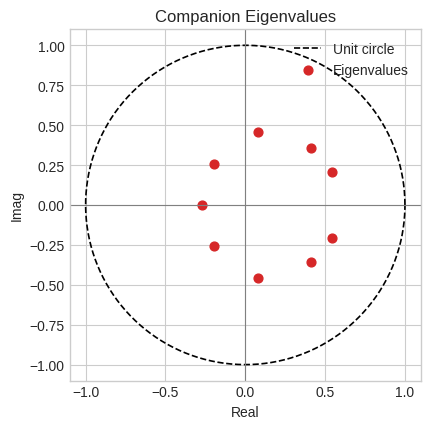

In [98]:
# 8) Companion matrix and stability check

def companion_matrix(coefs: np.ndarray) -> np.ndarray:
    p, k, _ = coefs.shape
    top = np.concatenate(coefs, axis=1)
    if p == 1:
        return top
    bottom = np.hstack([np.eye(k * (p - 1)), np.zeros((k * (p - 1), k))])
    return np.vstack([top, bottom])

def check_var_stability(coefs: np.ndarray, tol: float = 1e-10):
    A = companion_matrix(coefs)
    eigvals = np.linalg.eigvals(A)
    stable = np.all(np.abs(eigvals) < 1 - tol)
    return stable, eigvals

# 9) Run stability check

stable, eigvals = check_var_stability(results.coefs)
print("Is the VAR stable?", stable)
print("Eigenvalues:")
print(eigvals)
print("Absolute eigenvalues:")
print(np.abs(eigvals))
plot_stability_eigenvalues(eigvals)


--- 
## 5. MA Representation

A stable VAR admits an infinite-order moving-average representation. In lag-polynomial form:

$$
y_t = \mu + C(L)e_t, \qquad C(L)=\sum_{h=0}^{\infty} C_h L^h, \quad C_0=I_k.
$$

The coefficient matrices $C_h$ summarize dynamic propagation of reduced-form shocks $e_t$ across horizons.


In [99]:
# 10) Define VAR -> MA conversion

def var_to_ma(coefs: np.ndarray, horizon: int) -> np.ndarray:
    p, k, _ = coefs.shape
    C = np.zeros((horizon + 1, k, k))
    C[0] = np.eye(k)
    for h in range(1, horizon + 1):
        acc = np.zeros((k, k))
        for j in range(1, p + 1):
            if h - j >= 0:
                acc += coefs[j - 1] @ C[h - j]
        C[h] = acc
    return C
    
horizon = 20
ma_coefs = var_to_ma(results.coefs, horizon=horizon)
if not stable:
    print("Warning: VAR is not stable, so long-horizon MA/IRF may diverge.")
print("C_0:")
print(ma_coefs[0])
print("\nC_1:")
print(ma_coefs[1])


C_0:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

C_1:
[[0.6026 0.2551 0.1413]
 [0.0926 0.4593 0.003 ]
 [0.0496 0.3592 0.3451]]


---

## 6. Cholesky Identification

Reduced-form residuals $e_t$ are generally contemporaneously correlated, so they are not directly interpretable as orthogonal structural shocks. Cholesky identification introduces an impact matrix $P$ such that

$$
\Sigma_u = PP',\qquad e_t = Pu_t,\qquad \mathbb{E}[u_tu_t']=I_k.
$$

Here, $P$ is the lower-triangular Cholesky factor of $\Sigma_u$. Its $j$-th column gives the contemporaneous (horizon-0) effect of structural shock $u_j$ on all variables.

Because $P$ is lower triangular, identification depends on variable ordering: earlier variables can affect later variables contemporaneously, while the reverse contemporaneous effect is restricted to zero under this scheme.

With $e_t = Pu_t$, the MA representation

$$
y_t = \mu + C(L)e_t
$$

is rewritten as

$$
y_t = \mu + \tilde{C}(L)u_t, \qquad \tilde{C}(L)=C(L)P,
$$

so coefficient-by-coefficient, $\tilde{C}_h = C_hP$. Therefore, IRFs to structural shocks are read from $\tilde{C}_h$ rather than $C_h$.


In [100]:
# 12) Define Cholesky identification

def identify_cholesky(sigma_u: np.ndarray, ridge: float = 1e-10) -> np.ndarray:
    try:
        return np.linalg.cholesky(sigma_u)
    except np.linalg.LinAlgError:
        return np.linalg.cholesky(sigma_u + ridge * np.eye(sigma_u.shape[0]))


def compute_var_residuals(data: np.ndarray, results: VARResults, include_intercept: bool = True):
    Y, X = make_lag_matrix(data, results.p)
    T_eff = Y.shape[0]

    if include_intercept:
        X_design = np.hstack([np.ones((T_eff, 1)), X])
    else:
        X_design = X

    coef_flat = results.coefs.transpose(1, 0, 2).reshape(results.k, results.p * results.k).T
    if include_intercept:
        beta = np.vstack([results.intercept.reshape(1, -1), coef_flat])
    else:
        beta = coef_flat

    residuals = Y - (X_design @ beta)
    n_params = X_design.shape[1]
    return residuals, n_params

def compute_residual_covariance(residuals: np.ndarray, n_params: int) -> np.ndarray:
    T_eff = residuals.shape[0]
    dof = T_eff - n_params
    if dof <= 0:
        raise ValueError(f"Non-positive dof: T_eff={T_eff}, n_params={n_params}")
    return (residuals.T @ residuals) / dof


# 13) Compute residual covariance Sigma_u and impact matrix P
residuals, n_params = compute_var_residuals(data, results, include_intercept=include_intercept)
sigma_u = compute_residual_covariance(residuals, n_params=n_params)
results.residuals = residuals
results.sigma_u = sigma_u

print("Residual covariance Sigma_u:")
print(results.sigma_u)

impact_matrix = identify_cholesky(results.sigma_u)
print("Impact matrix P (Cholesky):")
print(impact_matrix)


Residual covariance Sigma_u:
[[ 0.8541  0.0478 -0.0082]
 [ 0.0478  0.9672 -0.0628]
 [-0.0082 -0.0628  1.0286]]
Impact matrix P (Cholesky):
[[ 0.9242  0.      0.    ]
 [ 0.0517  0.9821  0.    ]
 [-0.0089 -0.0635  1.0122]]


--- 
## 7. IRF Computation

Impulse responses are read from structural MA coefficients:

$$
\tilde{C}_h = C_hP,
\qquad
\mathrm{IRF}_{ij}(h) = \frac{\partial y_{i,t+h}}{\partial u_t^{(j)}} = (\tilde{C}_h)_{ij}.
$$

Interpretation of the formula:

- $C_h$: reduced-form propagation at horizon $h$ (response to $e_t$).
- $P$: contemporaneous impact matrix from Cholesky identification ($e_t=Pu_t$).
- $\tilde{C}_h$: structural propagation at horizon $h$ (response to $u_t$).

Because the system is linear, a one-unit shock in $u_t^{(j)}$ scales responses proportionally; therefore the partial derivative equals the $(i,j)$ entry of $\tilde{C}_h$.

The element $(i,j)$ of $\tilde{C}_h$ is interpreted as the response of variable $i$ at horizon $h$ to a one-unit structural shock in variable $j$ at time $t$.

Example notation: `y1 <- y2_shock` denotes the response path of `y1` to the second structural shock.

Time index note: IRFs are defined in relative time. A one-unit shock is applied at reference time $t$ (equivalently normalized as time 0), and horizon $h$ reports the response at $t+h$. Under a stable linear VAR, the IRF depends on $h$ and variable/shock indices, not on calendar time $t$.


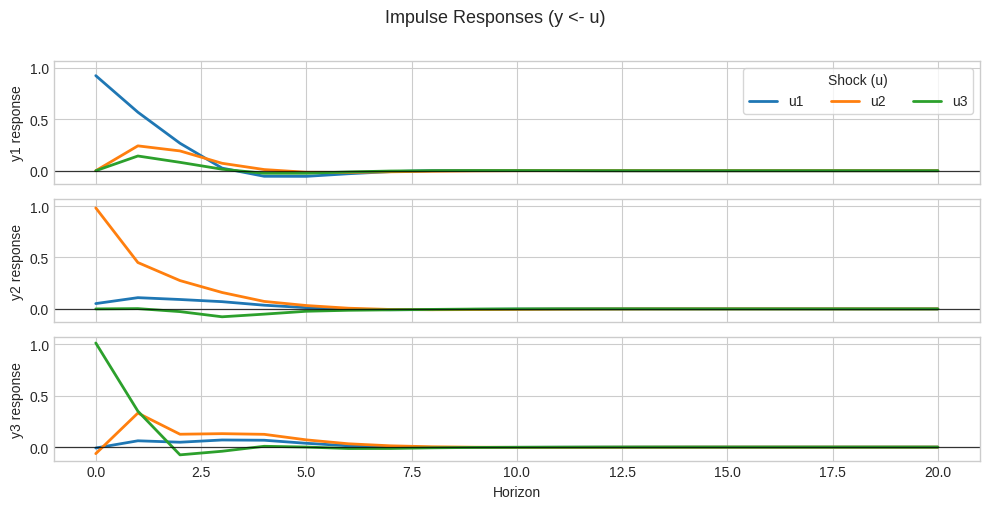

In [101]:
# 14) Define IRF computation

def compute_irf(ma_coefs: np.ndarray, impact_matrix: np.ndarray) -> np.ndarray:
    # irf[h, i, j] = response of y_i at horizon h to a one-unit structural shock u_j
    return np.einsum("hij,jk->hik", ma_coefs, impact_matrix)

# 15) Compute IRFs
irf = compute_irf(ma_coefs, impact_matrix)

# 16) Plot IRFs
shock_names = [f"u{j + 1}" for j in range(len(var_names))]
plot_irf(irf=irf, var_names=var_names, shock_names=shock_names, figsize=(10,5), layout="response_panels")
